# Lab Instructions

Find a dataset that interests you. I'd recommend starting on [Kaggle](https://www.kaggle.com/). Read through all of the material about the dataset and download a .CSV file.

1. Write a short summary of the data.  Where did it come from?  How was it collected?  What are the features in the data?  Why is this dataset interesting to you?  

2. Identify 5 interesting questions about your data that you can answer using Pandas methods.  

3. Answer those questions!  You may use any method you want (including LLMs) to help you write your code; however, you should use Pandas to find the answers.  LLMs will not always write code in this way without specific instruction.  

4. Write the answer to your question in a text box underneath the code you used to calculate the answer.



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns


df = pd.read_csv('Cars.csv', encoding='cp1252')


def clean_numeric_range(value):
    """Handles strings like '$1,200', '12000-15000', or '340 km/h'."""
    if pd.isna(value) or value == '':
        return None
    
    # Remove symbols and units
    clean_val = str(value).replace('$', '').replace(',', '').replace('km/h', '').replace('s', '').strip()
    
    # Handle ranges ('12000-15000') by averaging them
    if '-' in clean_val:
        try:
            parts = clean_val.split('-')
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return None

    try:
        return float(clean_val)
    except:
        return None

#APPLY CLEANING
df['Price_Clean'] = df['Cars Prices'].apply(clean_numeric_range)
df['Speed_Clean'] = df['Total Speed'].apply(clean_numeric_range)
df['Accel_Clean'] = df['Performance(0 - 100 )KM/H'].apply(clean_numeric_range)
#Create Full Name column
df['Full Name'] = df['Company Names'].str.upper() + " " + df['Cars Names'].str.upper()

df.head()

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque,Price_Clean,Speed_Clean,Accel_Clean,Full Name
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm,1100000.0,340.0,NaN,FERRARI SF90 STRADALE
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm,460000.0,250.0,NaN,ROLLS ROYCE PHANTOM
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm,13500.0,165.0,NaN,FORD KA+
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm,161000.0,250.0,NaN,MERCEDES GT 63 S
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm,253290.0,320.0,NaN,AUDI AUDI R8 GT


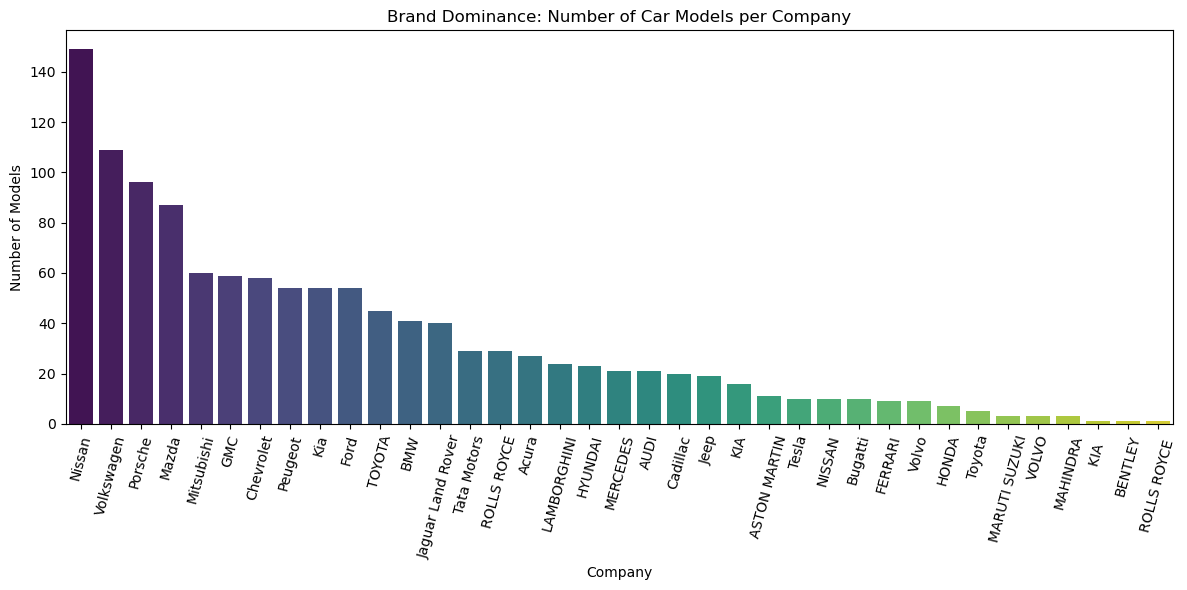

In [2]:
plt.figure(figsize=(12, 6))
brand_counts = df['Company Names'].value_counts()
sns.barplot(
    x=brand_counts.index, 
    y=brand_counts.values, 
    hue=brand_counts.index,  
    palette='viridis', 
    legend=False
)
plt.title('Brand Dominance: Number of Car Models per Company')
plt.xlabel('Company')
plt.ylabel('Number of Models')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

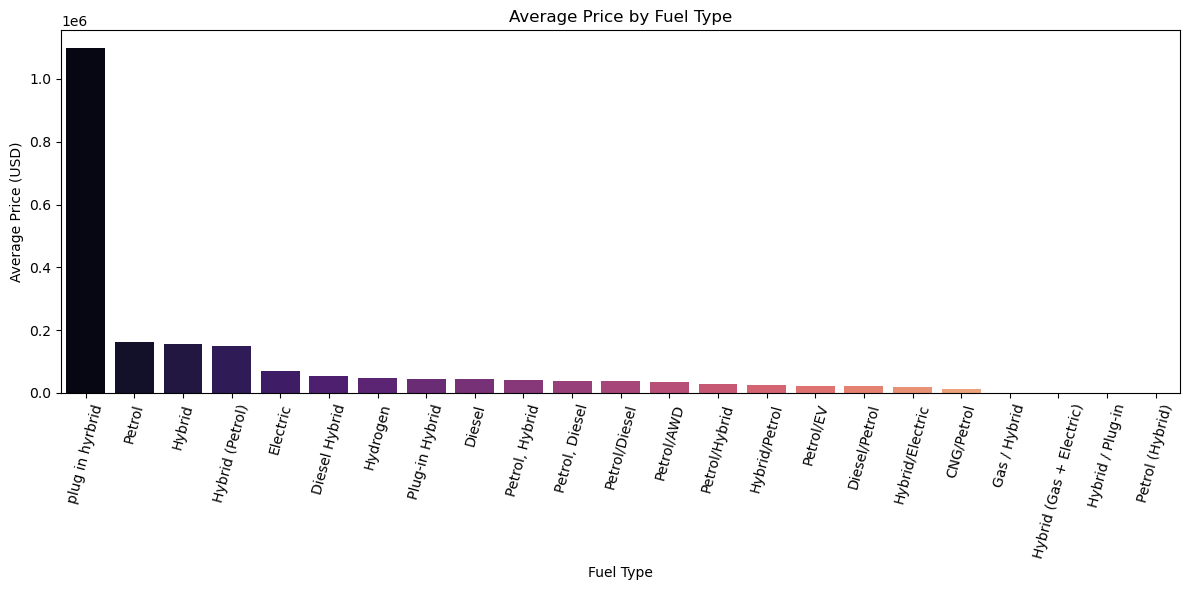

In [3]:
plt.figure(figsize=(12, 6))
avg_price_fuel = df.groupby('Fuel Types')['Price_Clean'].mean().sort_values(ascending=False)
sns.barplot(
    x=avg_price_fuel.index, 
    y=avg_price_fuel.values, 
    hue=avg_price_fuel.index, 
    palette='magma', 
    legend=False             
)
plt.title('Average Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

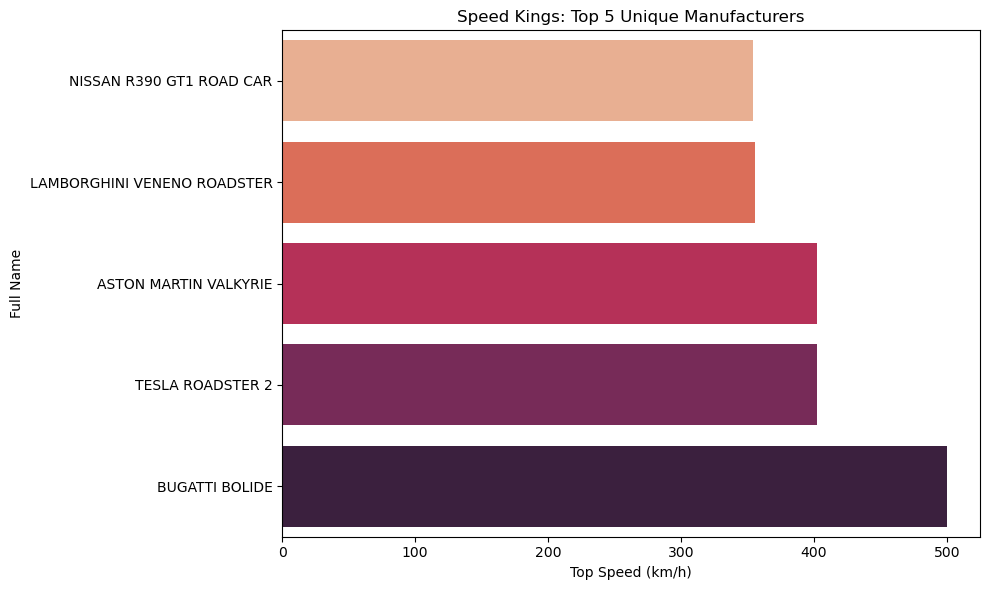

In [4]:
plt.figure(figsize=(10, 6))
top_5_speed = df.sort_values(by='Speed_Clean', ascending=False) \
                .drop_duplicates(subset='Company Names') \
                .head(5)
sns.barplot(
    x='Speed_Clean', 
    y='Full Name', 
    data=top_5_speed, 
    hue='Full Name', 
    palette='rocket', 
    legend=False      
)

plt.gca().invert_yaxis() 
plt.title('Speed Kings: Top 5 Unique Manufacturers')
plt.xlabel('Top Speed (km/h)')
plt.tight_layout()
plt.show()

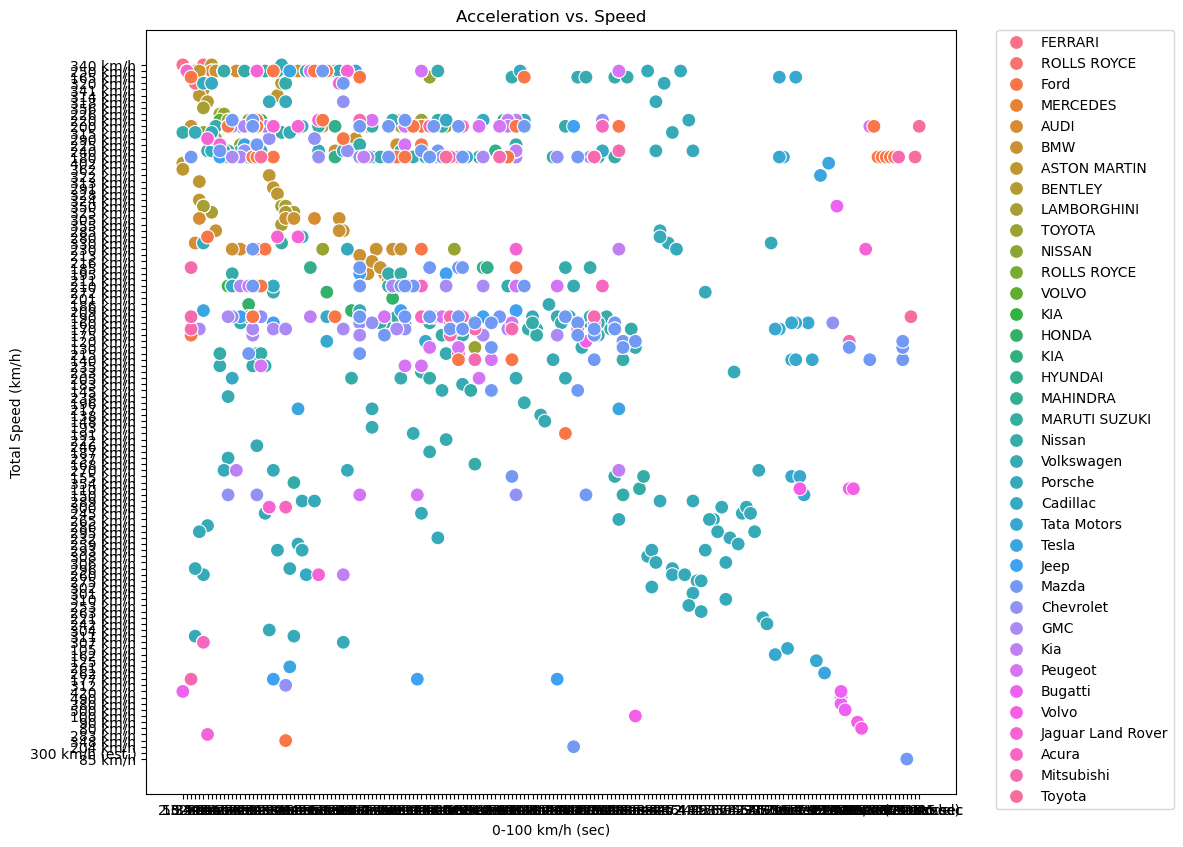

In [5]:
plt.figure(figsize=(12, 9))
sns.scatterplot(x='Performance(0 - 100 )KM/H', y='Total Speed', data=df, hue='Company Names', s=100)

plt.title('Acceleration vs. Speed')
plt.xlabel('0-100 km/h (sec)')
plt.ylabel('Total Speed (km/h)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

C:\Users\Candace\AppData\Local\Temp\ipykernel_1848\3181937611.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seat_counts.index, y=seat_counts.values, palette='viridis')


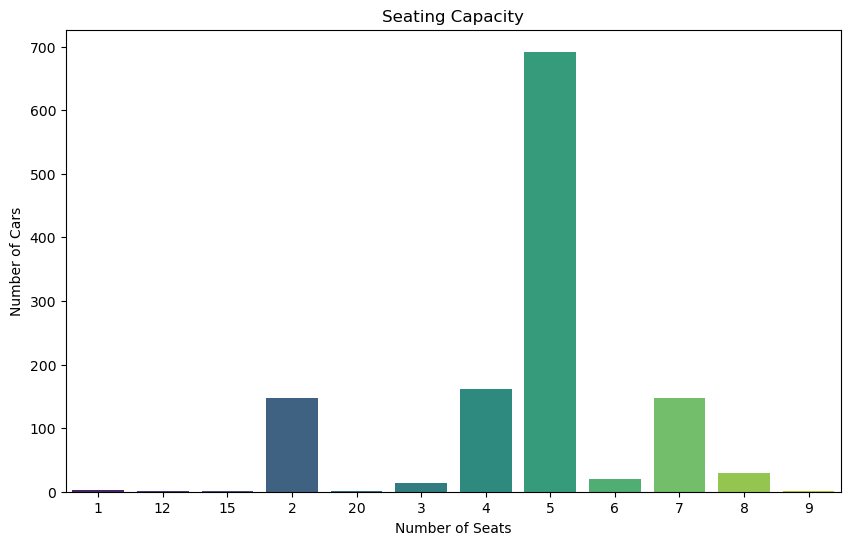

In [ ]:
plt.figure(figsize=(10, 6))

df['Seats_Clean'] = df['Seats'].astype(str).str.extract('(\d+)')

seat_counts = df['Seats_Clean'].value_counts().sort_index()

sns.barplot(x=seat_counts.index, y=seat_counts.values, palette='viridis')

plt.title('Seating Capacity')
plt.xlabel('Number of Seats')
plt.ylabel('Number of Cars')
plt.show()


The dataset analyzed for this project, was obtained from Kaggle. (https://www.kaggle.com/datasets/emmanuelnkobie/car-dataset) 



 The features include Company and Car Names, Total Speed (km/h), Acceleration (0-100 km/h), Fuel Types, Prices, and Seating Capacity. For someone who loves speed, this dataset is a "gold mine" because it doesn't just list everyday commuters; it focuses on the engineering marvels that define the modern era of racing and luxury.

The 5 Key Questions Answered
1. Which brand dominates the performance market? Using the value_counts() method, the analysis identified which manufacturers are the most prolific in the high-performance space. By counting how many models each company has in the dataset, we can see which brands are pushing the most variety into the speed market. This shows that while some brands focus on a single "speed king," others are flooding the 2026 market with multiple high-velocity options.

2. How does fuel type impact the average price of speed? 
By grouping the data by Fuel Type and calculating the average price, a clear trend emerged regarding the cost of performance. The data reveals that while Petrol engines are the traditional heart of the speed world, the transition to Electric and Hybrid power comes with a massive price premium. This highlights that in 2026, the highest levels of speed and "instant torque" are often reserved for those willing to pay for cutting-edge battery technology.

3. Who are the top 5 unique "Speed Kings"? 
To keep the leaderboard exciting, I used sort_values and drop_duplicates to identify the fastest car from five different manufacturers. This prevented the list from being five identical Bugattis and made it diverse. The Bugatti Bolide claimed the top spot, followed by Tesla, Aston Martin, Lamborghini, and the legendary Nissan R390 GT1. This leaderboard is a perfect visual for any speed enthusiast, as it ranks the absolute best from the world’s top engineers.

4. Is there a clear leader in 0-100 km/h acceleration?  
Using a scatter plot, I mapped Acceleration vs. Top Speed to see if the fastest cars are also the quickest off the line. Highlighting the leader (the Bugatti Bolide) with an annotation shows exactly which car wins the "drag race" compared to the rest of the pack.

5. What is the most common seating configuration for these fast cars? 
While the top speed leaders of the dataset are exclusive 2-seat hypercars like the Bugatti Bolide and Nissan R390 GT1, the data reveals that the 5-seat configuration is actually the most common layout across the entire collection. Performance SUV categories now make up the bulk of the high-velocity market, manufacturers are prioritizing speed that can be shared with more than one passenger.